# Model generation & validation
We will try a few different classifier to create a model which can predict customer churning for the provided energy data, we will be try a few different modelling techniques here-

1. logistic regression
2. random forest
3. xgboost
4. lightGBM

In [1]:
import sys, os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# importing nessaary util functions
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), ".")))
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [2]:
# importing nessaary util functions
from utils.utils import split_data, apply_smote, train_model, tune_model_with_gridsearch

In [3]:
# processed_df_path should go in the config.yaml
df_path = "../data/processed/churn_data_feat_eng.csv"
df = pd.read_csv(df_path)

In [4]:
df.head()

,UsageData,BillingAmount,CostPerUnit,ContractDuration,IsShortContractedCust,HighUsageFlag,CustomerServiceInteractions,Complaints,PromotionsReceived,PaymentHistory,ContractType,Age,Gender,Income,BilltoIncomeRatio,HouseholdSize,is_churned
0,880.922970,100.441977,0.114019,16,0,1,2,0,0,1,1,18,0,57732,574.779608,2,0
1,495.978553,176.144725,0.355146,12,0,0,1,0,2,1,1,51,0,84085,477.363145,3,0
2,311.763191,145.690171,0.467310,15,0,0,2,0,0,1,0,21,1,51898,356.221697,5,0
3,414.412773,105.305217,0.254107,13,0,0,4,1,3,1,1,23,0,72227,685.882448,3,0
4,244.697028,52.308319,0.213768,17,0,0,5,2,3,1,0,41,1,37707,720.860481,1,0


In [5]:
df.dtypes

UsageData                      float64
BillingAmount                  float64
CostPerUnit                    float64
ContractDuration                 int64
IsShortContractedCust            int64
HighUsageFlag                    int64
CustomerServiceInteractions      int64
Complaints                       int64
PromotionsReceived               int64
PaymentHistory                   int64
ContractType                     int64
Age                              int64
Gender                           int64
Income                           int64
BilltoIncomeRatio              float64
HouseholdSize                    int64
is_churned                       int64
dtype: object

In [ ]:
# convert neccesary variables to category or factors

In [6]:
from sklearn.preprocessing import MinMaxScaler

#Make a copy of only the features you want to scale
score_features = ['Complaints', 'CustomerServiceInteractions', 'HighUsageFlag', 'CostPerUnit', 'BilltoIncomeRatio', 'PromotionsReceived']
features_copy = df[score_features].copy()

#Scale the features temporarily
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features_copy), columns=score_features)

#Invert the negative indicators
for col in ['Complaints', 'CustomerServiceInteractions', 'HighUsageFlag', 'CostPerUnit']:
    features_scaled[col] = 1 - features_scaled[col]

#Calculate the satisfaction score
df['SatisfactionScore'] = features_scaled.mean(axis=1)

In [7]:
df.head()

,UsageData,BillingAmount,CostPerUnit,ContractDuration,IsShortContractedCust,HighUsageFlag,CustomerServiceInteractions,Complaints,PromotionsReceived,PaymentHistory,ContractType,Age,Gender,Income,BilltoIncomeRatio,HouseholdSize,is_churned,SatisfactionScore
0,880.922970,100.441977,0.114019,16,0,1,2,0,0,1,1,18,0,57732,574.779608,2,0,0.444438
1,495.978553,176.144725,0.355146,12,0,0,1,0,2,1,1,51,0,84085,477.363145,3,0,0.749969
2,311.763191,145.690171,0.467310,15,0,0,2,0,0,1,0,21,1,51898,356.221697,5,0,0.611069
3,414.412773,105.305217,0.254107,13,0,0,4,1,3,1,1,23,0,72227,685.882448,3,0,0.638870
4,244.697028,52.308319,0.213768,17,0,0,5,2,3,1,0,41,1,37707,720.860481,1,0,0.527763


In [8]:
#split data
X_train, X_test, y_train, y_test = split_data(df, target='is_churned')

In [9]:
y_train.value_counts()

is_churned
0    8666
1     934
Name: count, dtype: int64

In [10]:
# Then apply SMOTE to the training set only
X_train_bal, y_train_bal = apply_smote(X_train, y_train, scale=True, tomek=True)
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)

In [11]:
y_train_bal.value_counts()

is_churned
0    8651
1    8651
Name: count, dtype: int64

In [38]:
#Train logistic classifier using the train_model function
logistic_model, logistic_results = train_model(X_train    = X_train_bal, 
                                               y_train    = y_train_bal, 
                                               X_test     = X_test, 
                                               y_test     = y_test, 
                                               model_name ='logistic'
)

In [15]:
#Print evaluation metrics
print("Logistic classifier Performance:")
for metric, value in logistic_results.items():
    print(f"{metric}: {value:.4f}")

Logistic classifier Performance:
accuracy: 0.8950
precision: 0.0476
recall: 0.0043
f1_score: 0.0079
roc_auc: 0.4831


In [12]:
#Train logistic classifier using the train_model function
dt_model, dt_results = train_model(X_train    = X_train_bal, 
                                               y_train    = y_train_bal, 
                                               X_test     = X_test, 
                                               y_test     = y_test, 
                                               model_name ='decision_tree'
)

In [13]:
#Print evaluation metrics
print("decision tree classifier Performance:")
for metric, value in dt_results.items():
    print(f"{metric}: {value:.4f}")

decision tree classifier Performance:
accuracy: 0.2783
precision: 0.0938
recall: 0.7425
f1_score: 0.1665
roc_auc: 0.4855


In [16]:
#Train support vector machine using the train_model function
svm_model, svm_results = train_model(X_train    = X_train_bal, 
                                               y_train    = y_train_bal, 
                                               X_test     = X_test, 
                                               y_test     = y_test, 
                                               model_name ='svm'
)

In [17]:
#Print evaluation metrics
print("support vector machine Performance:")
for metric, value in svm_results.items():
    print(f"{metric}: {value:.4f}")

support vector machine Performance:
accuracy: 0.9029
precision: 0.0000
recall: 0.0000
f1_score: 0.0000
roc_auc: 0.5000


In [18]:
#Train Random forest using the train_model function
random_forest_model, random_forest_results = train_model(X_train    = X_train, 
                                               y_train    = y_train, 
                                               X_test     = X_test, 
                                               y_test     = y_test, 
                                               model_name ='random_forest'
)

In [19]:
#Print evaluation metrics
print("Random forest Performance:")
for metric, value in random_forest_results.items():
    print(f"{metric}: {value:.4f}")

Random forest Performance:
accuracy: 0.9029
precision: 0.0000
recall: 0.0000
f1_score: 0.0000
roc_auc: 0.4920


In [20]:
#Train lightgbm using the train_model function
lightgbm_model, lightgbm_results = train_model(X_train    = X_train_bal, 
                                               y_train    = y_train_bal, 
                                               X_test     = X_test, 
                                               y_test     = y_test, 
                                               model_name ='lightgbm'
)

[LightGBM] [Info] Number of positive: 8651, number of negative: 8651
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3699
[LightGBM] [Info] Number of data points in the train set: 17302, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [21]:
#Print evaluation metrics
print("lightgbm Performance:")
for metric, value in lightgbm_results.items():
    print(f"{metric}: {value:.4f}")

lightgbm Performance:
accuracy: 0.2442
precision: 0.0948
recall: 0.7940
f1_score: 0.1694
roc_auc: 0.4724


In [22]:
#Train xgboost using the train_model function
xgboost_model, xgboost_results = train_model(X_train    = X_train_bal, 
                                               y_train    = y_train_bal, 
                                               X_test     = X_test, 
                                               y_test     = y_test, 
                                               model_name ='xgboost'
)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:39:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [23]:
#Print evaluation metrics
print("xgboost Performance:")
for metric, value in xgboost_results.items():
    print(f"{metric}: {value:.4f}")

xgboost Performance:
accuracy: 0.2958
precision: 0.0946
recall: 0.7296
f1_score: 0.1675
roc_auc: 0.4812


In [24]:
xgb_model, xgb_best_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='xgboost', scoring='f1')
print("Best Parameters:", xgb_best_params)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:40:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:40:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:40:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:40:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 1, 'subsample': 0.8}


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1] if hasattr(xgb_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}

In [27]:
metrics

{'accuracy': 0.20291666666666666,
 'precision': 0.09770114942528736,
 'recall': 0.8755364806866953,
 'f1_score': 0.17578629900904783,
 'roc_auc': 0.4908181837987289}

In [28]:
lightgbm_model, lightgbm_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='lightgbm', scoring='accuracy')
print("Best Parameters:", lightgbm_params)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[LightGBM] [Info] Number of positive: 6921, number of negative: 6920
[LightGBM] [Info] Number of positive: 6921, number of negative: 6921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001879 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3683
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3691
[LightGBM] [Info] Number of data points in the train set: 13842, number of used features: 17
[LightGBM] [Info] Number of data points in the train set: 13841, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500036 -> initscore=0.000144
[LightGBM] [Info] Start training from score 0.000144
[LightGBM] [Info] [binary:

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = lightgbm_model.predict(X_test)
y_prob = lightgbm_model.predict_proba(X_test)[:, 1] if hasattr(lightgbm_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.17291666666666666,
 'precision': 0.0959409594095941,
 'recall': 0.8927038626609443,
 'f1_score': 0.17326114119117034,
 'roc_auc': 0.46115850120120183}

In [31]:
rf_best_model, rf_best_params = tune_model_with_gridsearch(X_train, y_train, model_type='random_forest', scoring='f1')
print("Best Parameters:", rf_best_params)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = rf_best_model.predict(X_test)
y_prob = rf_best_model.predict_proba(X_test)[:, 1] if hasattr(rf_best_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.7604166666666666,
 'precision': 0.06153846153846154,
 'recall': 0.10300429184549356,
 'f1_score': 0.07704654895666131,
 'roc_auc': 0.4979035909298866}

/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_17294/3588500736.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


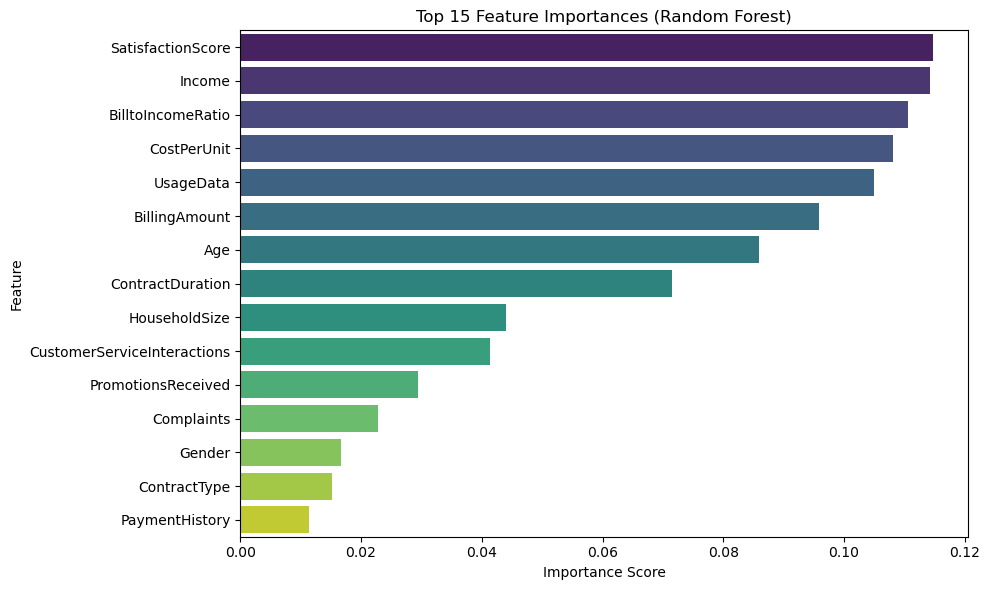

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Prepare data
X = X_train
y = y_train

# Optional: scale if needed (not required for RandomForest)
# from sklearn.preprocessing import StandardScaler
# X = StandardScaler().fit_transform(X)

# Step 2: Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Step 3: Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Step 4: Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()